# Pruning in Machine Learning — Konzept, Beispiele & Visualisierung
---

## Kernidee in einem Satz

> **Pruning** (engl. *to prune* = beschneiden, zurückschneiden) bezeichnet das **gezielte Entfernen von Modellteilen, die wenig zur Vorhersage beitragen** — um Überanpassung (Overfitting) zu verringern, das Modell kleiner und schneller zu machen und es besser interpretierbar zu halten.

Dabei begegnet uns derselbe Grundgedanke in drei sehr unterschiedlichen Kontexten, die wir in diesem Notebook nacheinander **visuell** durchspielen:

| Kontext | Was wird „abgeschnitten"? | Ziel |
|---|---|---|
| **Entscheidungsbaum / Random Forest** | Knoten / Teilbäume | weniger Overfitting, kleinere Bäume |
| **Neuronales Netz** | einzelne Gewichte / Neuronen | Kompression, schnellere Inferenz |
| **Optuna (Hyperparameter-Suche)** | aussichtslose *Trials* (früher Abbruch) | Rechenzeit sparen |


## 0 · Setup

Wir setzen ein einheitliches Farbschema (Dunkelblau `#1B3A5C`, Mittelblau `#2E75B6`) und eine Akzentfarbe für „beschnittene" Elemente.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# --- Hausfarben ---
DARK   = "#1B3A5C"   # Dunkelblau
MID    = "#2E75B6"   # Mittelblau
LIGHT  = "#9DC3E6"   # Hellblau
PRUNE  = "#C0504D"   # Akzent: "beschnitten"
GREY   = "#BFBFBF"

plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "axes.titlesize": 13, "axes.titlecolor": DARK, "axes.titleweight": "bold",
    "axes.labelcolor": DARK, "axes.edgecolor": DARK,
    "xtick.color": DARK, "ytick.color": DARK,
    "axes.grid": True, "grid.alpha": 0.25, "font.size": 11,
})
cmap_blue = LinearSegmentedColormap.from_list("hb", ["white", LIGHT, MID, DARK])
np.random.seed(42)
print("Setup ok.")

Setup ok.


---
# Teil 1 · Entscheidungsbaum-Pruning

Ein unbeschnittener Entscheidungsbaum wächst so lange, bis er die **Trainingsdaten quasi auswendig** kann (jedes Blatt enthält nur noch wenige, „reine" Beispiele). Auf Trainingsdaten ist die Genauigkeit dann fast 100 % — auf **neuen** Daten bricht sie ein. Das ist **Overfitting**.

**Zwei Strategien:**

- **Pre-Pruning** (vorab bremsen): Wachstum von vornherein begrenzen, z. B. `max_depth`, `min_samples_leaf`, `min_impurity_decrease`.
- **Post-Pruning** (nachträglich zurückschneiden): Baum erst voll wachsen lassen, dann unnütze Teilbäume entfernen. Standardverfahren in scikit-learn: **Cost-Complexity Pruning (CCP)**.

### Cost-Complexity Pruning — das Kostenmaß

Für einen (Teil-)Baum $T$ mit der Fehler-/Impuritätssumme $R(T)$ und $\tilde T$ Blättern definiert man die **kostenkomplexe Bewertung**:

$$R_\alpha(T) \;=\; R(T) \;+\; \alpha \cdot \tilde T$$

- $R(T)$ = wie gut der Baum die Daten trifft (kleiner = besser),
- $\tilde T$ = Anzahl der Blätter (= Modellkomplexität),
- $\alpha \ge 0$ = **„Strafpreis" pro Blatt**.

Je größer $\alpha$, desto teurer wird jedes zusätzliche Blatt → der Baum wird **stärker beschnitten**. Bei $\alpha = 0$ bleibt der volle Baum, bei sehr großem $\alpha$ bleibt nur die Wurzel.

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

X, y = load_breast_cancer(return_X_y=True) # Daten laden (Scikitlearn integrierte Datasets)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Vollen Baum trainieren und den CCP-Pfad berechnen
full = DecisionTreeClassifier(random_state=42).fit(Xtr, ytr)
path = full.cost_complexity_pruning_path(Xtr, ytr)
alphas = path.ccp_alphas[:-1]          # letztes alpha = nur Wurzel, weglassen

acc_tr, acc_te, n_nodes = [], [], []
for a in alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=a).fit(Xtr, ytr)
    acc_tr.append(clf.score(Xtr, ytr))
    acc_te.append(clf.score(Xte, yte))
    n_nodes.append(clf.tree_.node_count)

best = int(np.argmax(acc_te))
print(f"Unbeschnitten : {n_nodes[0]:3d} Knoten | Test-Genauigkeit {acc_te[0]:.3f}")
print(f"Bestes alpha  : {alphas[best]:.5f}")
print(f"Beschnitten   : {n_nodes[best]:3d} Knoten | Test-Genauigkeit {acc_te[best]:.3f}")

Unbeschnitten :  31 Knoten | Test-Genauigkeit 0.918
Bestes alpha  : 0.00295
Beschnitten   :  17 Knoten | Test-Genauigkeit 0.936


### Visualisierung 1 — Genauigkeit & Baumgröße in Abhängigkeit von $\alpha$

Die zentrale Pruning-Kurve: Trainingsgenauigkeit sinkt monoton, **Testgenauigkeit hat ein Maximum** — genau dort liegt der „sweet spot" zwischen zu komplex (links) und zu stark beschnitten (rechts).

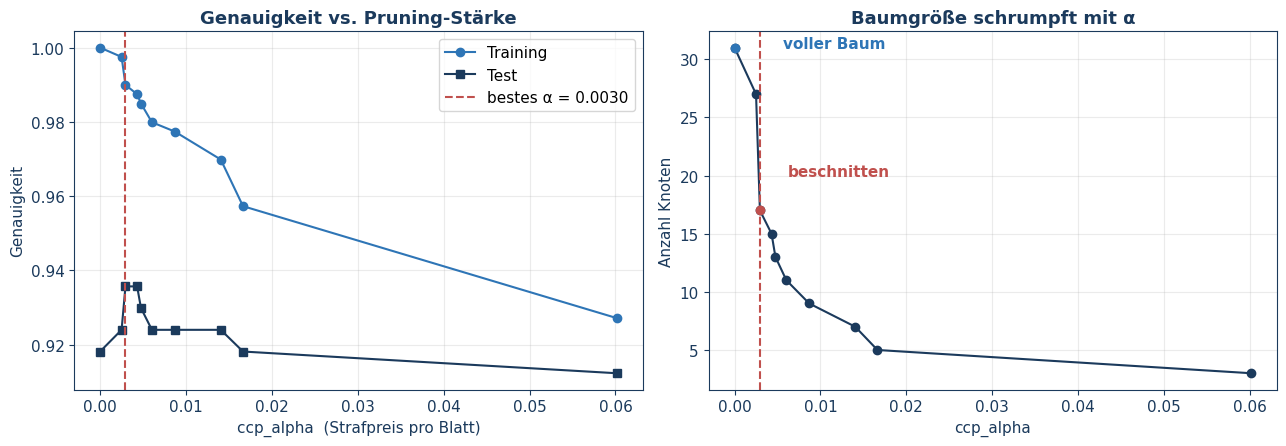

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))

ax1.plot(alphas, acc_tr, "o-", color=MID,  label="Training")
ax1.plot(alphas, acc_te, "s-", color=DARK, label="Test")
ax1.axvline(alphas[best], color=PRUNE, ls="--", lw=1.5, label=f"bestes α = {alphas[best]:.4f}")
ax1.set_xlabel("ccp_alpha  (Strafpreis pro Blatt)"); ax1.set_ylabel("Genauigkeit")
ax1.set_title("Genauigkeit vs. Pruning-Stärke"); ax1.legend()

ax2.plot(alphas, n_nodes, "o-", color=DARK)
ax2.axvline(alphas[best], color=PRUNE, ls="--", lw=1.5)
ax2.scatter([alphas[0]], [n_nodes[0]], color=MID, zorder=5)
ax2.annotate("voller Baum", (alphas[0], n_nodes[0]), textcoords="offset points",
             xytext=(35, 0), color=MID, fontweight="bold")
ax2.scatter([alphas[best]], [n_nodes[best]], color=PRUNE, zorder=5)
ax2.annotate("beschnitten", (alphas[best], n_nodes[best]), textcoords="offset points",
             xytext=(20, 25), color=PRUNE, fontweight="bold")
ax2.set_xlabel("ccp_alpha"); ax2.set_ylabel("Anzahl Knoten")
ax2.set_title("Baumgröße schrumpft mit α")
plt.tight_layout(); plt.show()

### 📐 Rechenbeispiel — wann lohnt sich ein Schnitt?

Beim CCP berechnet man für jeden inneren Knoten das **effektive $\alpha$**, ab dem es sich „lohnt", den ganzen Teilbalken unter ihm durch **ein einziges Blatt** zu ersetzen:

$$\alpha_{\text{eff}} \;=\; \frac{R(\text{Knoten als Blatt}) - R(\text{Teilbaum})}{|\tilde T_{\text{Teilbaum}}| - 1}$$

**Konkret:** Ein Teilbaum hat **3 Blätter** und einen Trainingsfehler (gewichtete Fehlerrate) von $R(T_{\text{sub}}) = 0{,}02$. Würden wir ihn zu **einem** Blatt zusammenfassen, läge der Fehler bei $R(\text{Blatt}) = 0{,}08$.

$$\alpha_{\text{eff}} = \frac{0{,}08 - 0{,}02}{3 - 1} = \frac{0{,}06}{2} = 0{,}03$$

**Interpretation:** Solange der gewählte Strafpreis $\alpha < 0{,}03$ ist, lohnt sich der detaillierte Teilbaum. Sobald $\alpha \ge 0{,}03$, wird der Teilbaum **abgeschnitten** — die 0,06 zusätzlicher Genauigkeit sind den 2 Extra-Blättern den Preis nicht mehr wert.

In [4]:
# Das Rechenbeispiel zur Kontrolle nachrechnen
R_subtree, R_leaf, n_leaves = 0.02, 0.08, 3
alpha_eff = (R_leaf - R_subtree) / (n_leaves - 1)
print(f"alpha_eff = ({R_leaf} - {R_subtree}) / ({n_leaves} - 1) = {alpha_eff:.3f}")
print("-> Für alpha >= 0.030 wird dieser Teilbaum zu einem Blatt zusammengeschnitten.")

alpha_eff = (0.08 - 0.02) / (3 - 1) = 0.030
-> Für alpha >= 0.030 wird dieser Teilbaum zu einem Blatt zusammengeschnitten.


### Visualisierung 2 — Entscheidungsgrenze: voll vs. beschnitten

An einem 2D-Datensatz (`make_moons`) sieht man Overfitting direkt: Der volle Baum produziert **zerklüftete, „inselartige" Grenzen** (er lernt das Rauschen mit). Der beschnittene Baum hat eine **glatte, allgemeingültige** Grenze.

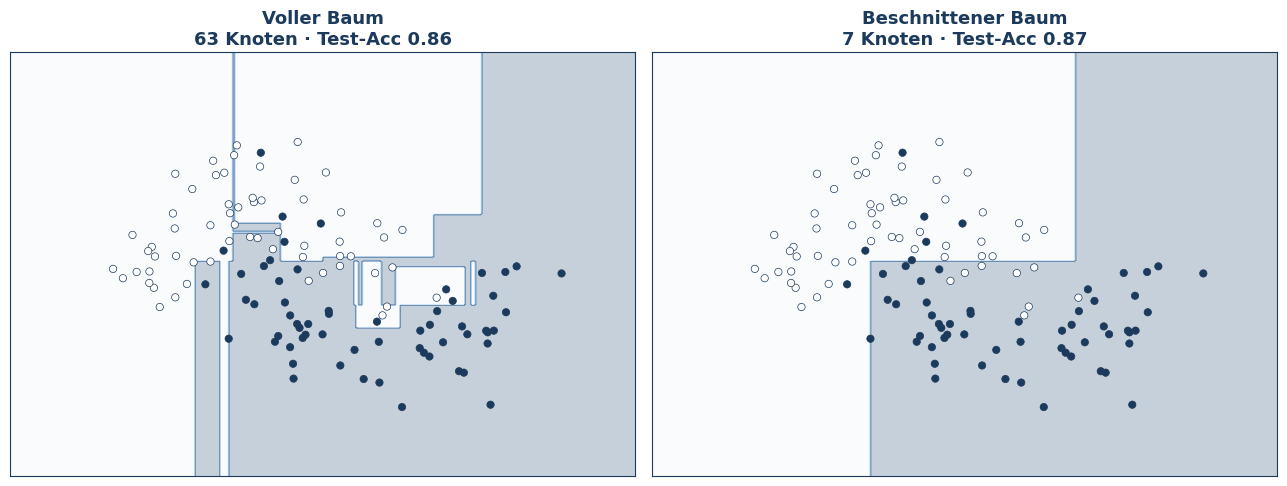

In [5]:
from sklearn.datasets import make_moons

Xm, ym = make_moons(n_samples=400, noise=0.30, random_state=3)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm, ym, test_size=0.3, random_state=3)

tree_full  = DecisionTreeClassifier(random_state=3).fit(Xm_tr, ym_tr)
tree_prune = DecisionTreeClassifier(random_state=3, ccp_alpha=0.02).fit(Xm_tr, ym_tr)

xx, yy = np.meshgrid(np.linspace(Xm[:,0].min()-.5, Xm[:,0].max()+.5, 300),
                     np.linspace(Xm[:,1].min()-.5, Xm[:,1].max()+.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, model, name in [(axes[0], tree_full,  "Voller Baum"),
                        (axes[1], tree_prune, "Beschnittener Baum")]:
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap=cmap_blue)
    ax.scatter(Xm_te[:,0], Xm_te[:,1], c=ym_te, cmap=cmap_blue,
               edgecolor=DARK, s=28, linewidth=0.5)
    ax.set_title(f"{name}\n{model.tree_.node_count} Knoten · Test-Acc {model.score(Xm_te,ym_te):.2f}")
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.tight_layout(); plt.show()

### Visualisierung 3 — derselbe Baum als Struktur

Hier sieht man buchstäblich, wie viele Verzweigungen wegfallen.

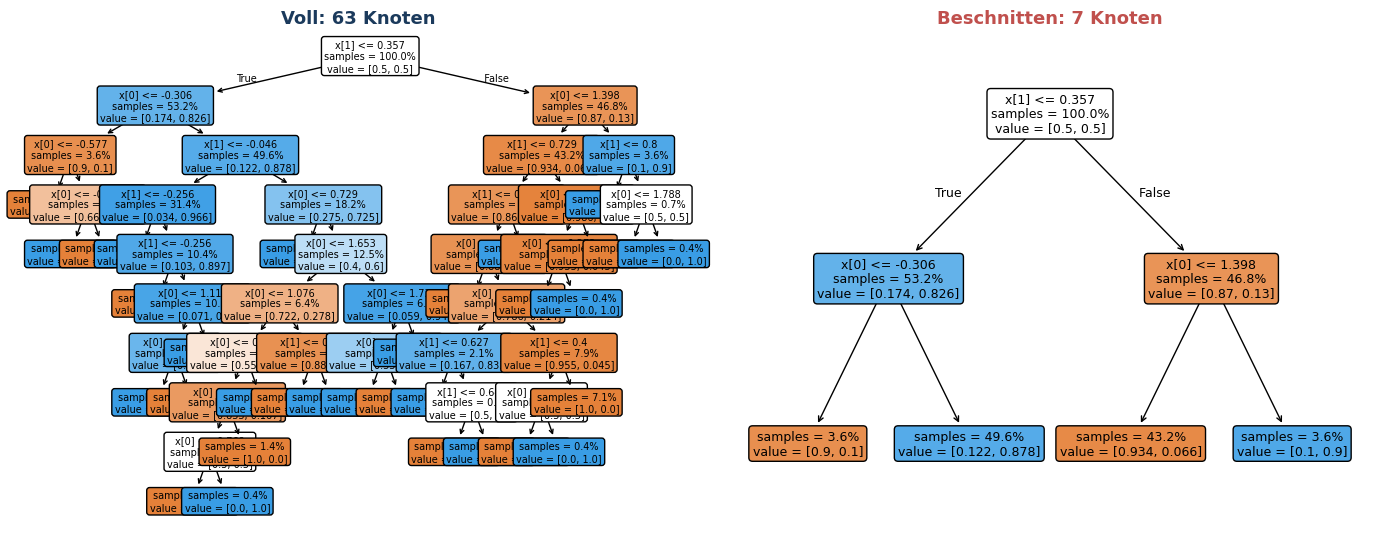

In [6]:
from sklearn.tree import plot_tree

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
plot_tree(tree_full,  ax=axes[0], filled=True, impurity=False, proportion=True,
          rounded=True, fontsize=7)
axes[0].set_title(f"Voll: {tree_full.tree_.node_count} Knoten", color=DARK, fontweight="bold")
plot_tree(tree_prune, ax=axes[1], filled=True, impurity=False, proportion=True,
          rounded=True, fontsize=9)
axes[1].set_title(f"Beschnitten: {tree_prune.tree_.node_count} Knoten", color=PRUNE, fontweight="bold")
plt.tight_layout(); plt.show()

> **Random Forest?** Einzelne Bäume eines Random Forest werden meist **nicht** beschnitten — der Wald reduziert Overfitting bereits durch Mittelung über viele Bäume (Bagging). „Pruning" beim Forest bedeutet daher eher: **Bäume *entfernen*** (Ensemble-Pruning) oder das Wachstum mit `max_depth`/`min_samples_leaf` begrenzen. Das Prinzip — *unnütze Komplexität raus* — bleibt identisch.

---
# Teil 2 · Pruning in neuronalen Netzen

Ein trainiertes Netz hat oft **viel mehr Gewichte als nötig**. Viele davon sind **betragsmäßig nahe null** und tragen kaum zur Ausgabe bei. Beim **Magnitude Pruning** entfernt man genau diese: man setzt die kleinsten Gewichte (nach Betrag) hart auf **0**.

**Zwei Varianten:**

- **Unstrukturiert:** einzelne Gewichte → 0 (erzeugt *dünn besetzte* Matrizen, sparse).
- **Strukturiert:** ganze Neuronen / Kanäle / Filter entfernen (erzeugt ein *echt kleineres* Netz, das ohne Spezial-Hardware schneller läuft).

**Bezug zu „Optima":** Erstaunlicherweise bleibt die Genauigkeit oft bis zu **70–90 % Sparsity** nahezu konstant. Das passt zur **Lottery-Ticket-Hypothese**: In einem großen Netz steckt bereits ein kleines, „gewinnendes" Teilnetz, das ein **ebenso gutes Optimum** repräsentiert. Pruning legt dieses Teilnetz frei.

### 📐 Rechenbeispiel — Magnitude Pruning

Gegeben eine Gewichtsschicht mit 8 Gewichten:

$$w = [\;0.81,\ -0.04,\ 0.55,\ 0.02,\ -0.77,\ 0.09,\ -0.01,\ 0.63\;]$$

Wir wollen **50 % Sparsity** (die Hälfte entfernen). Vorgehen:

1. Beträge bilden: $|w| = [0.81,\ 0.04,\ 0.55,\ 0.02,\ 0.77,\ 0.09,\ 0.01,\ 0.63]$
2. Schwelle = **Median** der Beträge (50 %-Quantil). Sortiert: $[0.01, 0.02, 0.04, 0.09, \mathbf{0.55}, 0.63, 0.77, 0.81]$ → Schwelle $\approx 0.32$.
3. Alle Gewichte mit $|w| < 0.32$ → **0** setzen.

$$w_{\text{pruned}} = [\;0.81,\ 0,\ 0.55,\ 0,\ -0.77,\ 0,\ 0,\ 0.63\;]$$

Die 4 kleinsten Gewichte (0.04, 0.02, 0.09, 0.01) sind weg — das Netz behält nur die „wichtigen" Verbindungen.

In [7]:
w = np.array([0.81, -0.04, 0.55, 0.02, -0.77, 0.09, -0.01, 0.63])
sparsity = 0.5
thr = np.quantile(np.abs(w), sparsity)
mask = np.abs(w) >= thr
w_pruned = w * mask
print("Schwelle (50%-Quantil):", round(thr, 3))
print("Original :", w)
print("Maske    :", mask.astype(int))
print("Beschnitten:", w_pruned)
print(f"-> {(~mask).sum()} von {len(w)} Gewichten entfernt ({100*(~mask).mean():.0f} % Sparsity)")

Schwelle (50%-Quantil): 0.32
Original : [ 0.81 -0.04  0.55  0.02 -0.77  0.09 -0.01  0.63]
Maske    : [1 0 1 0 1 0 0 1]
Beschnitten: [ 0.81 -0.    0.55  0.   -0.77  0.   -0.    0.63]
-> 4 von 8 Gewichten entfernt (50 % Sparsity)


### Training eines kleinen MLP & globales Magnitude Pruning

Wir trainieren ein MLP (`64 → 32` versteckte Neuronen) auf `make_moons` und nullen dann **global** die betragskleinsten Gewichte über alle Schichten hinweg.

In [8]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

Xn, yn = make_moons(n_samples=800, noise=0.22, random_state=0)
Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(Xn, yn, test_size=0.3, random_state=0)
scaler = StandardScaler().fit(Xn_tr)
Xn_tr_s, Xn_te_s = scaler.transform(Xn_tr), scaler.transform(Xn_te)

mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=3000,
                    random_state=1).fit(Xn_tr_s, yn_tr)
W_orig = [w.copy() for w in mlp.coefs_]                  # Originalgewichte sichern
all_w  = np.concatenate([w.ravel() for w in W_orig])     # alle Gewichte in einem Vektor
print(f"Schichten (Formen): {[w.shape for w in W_orig]}")
print(f"Gesamtzahl Gewichte: {all_w.size}")
print(f"Basis-Genauigkeit (0 % Sparsity): {mlp.score(Xn_te_s, yn_te):.3f}")

def prune_to(sparsity):
    # Globales unstrukturiertes Magnitude Pruning auf 'sparsity' Anteil
    thr = np.quantile(np.abs(all_w), sparsity)
    for i, w in enumerate(W_orig):
        mlp.coefs_[i] = w * (np.abs(w) >= thr)
    return mlp.score(Xn_te_s, yn_te)

levels = np.linspace(0, 0.97, 25)
accs   = [prune_to(s) for s in levels]
for i, w in enumerate(W_orig): mlp.coefs_[i] = w.copy()   # zurücksetzen

Schichten (Formen): [(2, 64), (64, 32), (32, 1)]
Gesamtzahl Gewichte: 2208
Basis-Genauigkeit (0 % Sparsity): 0.958


### Visualisierung 4 — Genauigkeit vs. Sparsity

Die typische Kurve: ein langes **Plateau** (man kann sehr viele Gewichte entfernen, ohne Schaden), dann ein **Abbruch**, wenn zu viel weggeschnitten wird.

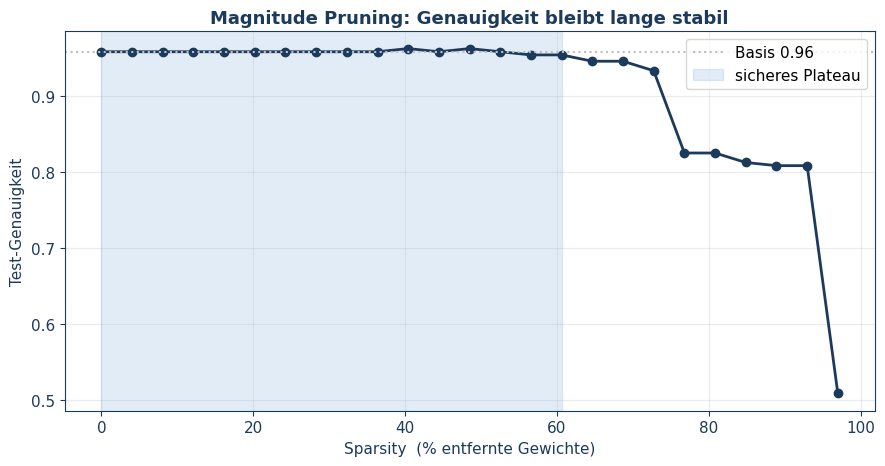

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(levels*100, accs, "o-", color=DARK, lw=2)
ax.axhline(accs[0], color=GREY, ls=":", label=f"Basis {accs[0]:.2f}")
# Plateau-Bereich markieren
plateau = levels[np.array(accs) >= accs[0]-0.01]
if len(plateau):
    ax.axvspan(0, plateau.max()*100, color=LIGHT, alpha=0.30, label="sicheres Plateau")
ax.set_xlabel("Sparsity  (% entfernte Gewichte)")
ax.set_ylabel("Test-Genauigkeit")
ax.set_title("Magnitude Pruning: Genauigkeit bleibt lange stabil")
ax.legend(); plt.tight_layout(); plt.show()

### Visualisierung 5 — Gewichtsverteilung vor/nach dem Pruning

Vor dem Pruning häufen sich viele Gewichte **um null**. Nach 70 % Sparsity sind genau diese verschwunden — übrig bleiben die „starken" Verbindungen in den Flanken.

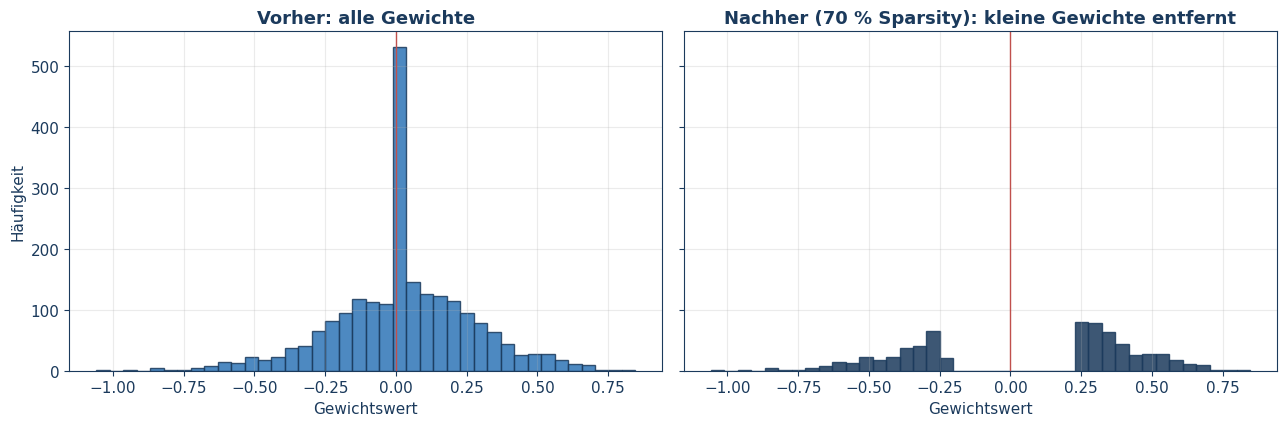

In [10]:
prune_to(0.70)
w_after = np.concatenate([w.ravel() for w in mlp.coefs_])
nz = w_after[w_after != 0]
for i, w in enumerate(W_orig): mlp.coefs_[i] = w.copy()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
a1.hist(all_w, bins=40, color=MID, edgecolor=DARK, alpha=0.85)
a1.axvline(0, color=PRUNE, lw=1); a1.set_title("Vorher: alle Gewichte")
a1.set_xlabel("Gewichtswert"); a1.set_ylabel("Häufigkeit")
a2.hist(nz, bins=40, color=DARK, edgecolor=DARK, alpha=0.85)
a2.axvline(0, color=PRUNE, lw=1)
a2.set_title("Nachher (70 % Sparsity): kleine Gewichte entfernt")
a2.set_xlabel("Gewichtswert")
plt.tight_layout(); plt.show()

### Visualisierung 6 — welche Verbindungen überleben?

Heatmap der **zweiten Gewichtsmatrix** (64 → 32). Weiß = auf 0 gesetzt (beschnitten), blau = aktiv. Bei 70 % Sparsity ist die Matrix sichtbar **dünn besetzt** (sparse).

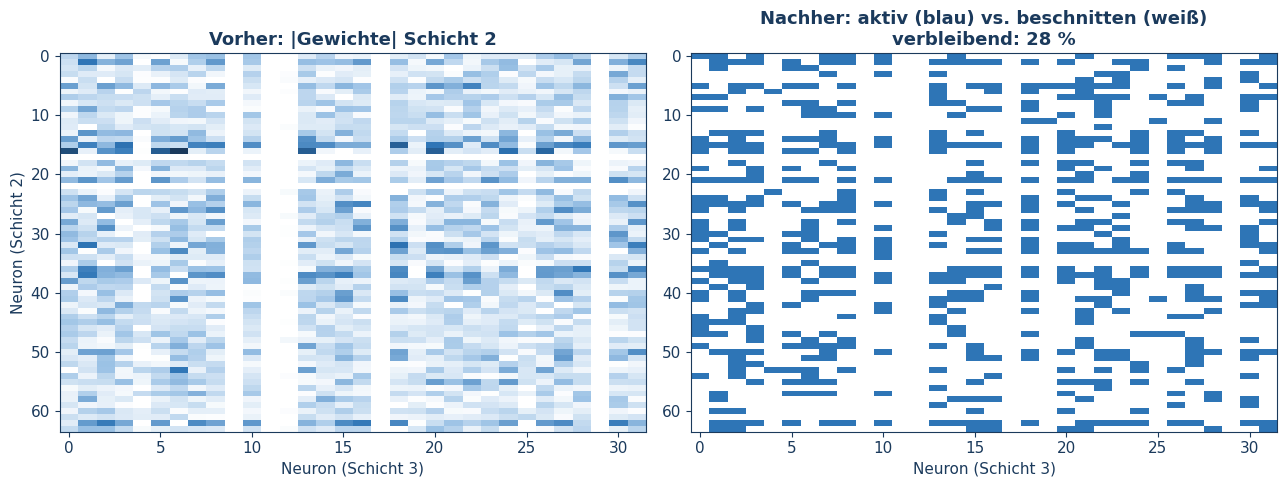

In [11]:
W2 = W_orig[1]                       # Form (64, 32)
prune_to(0.70)
W2_pruned = mlp.coefs_[1]
for i, w in enumerate(W_orig): mlp.coefs_[i] = w.copy()

fig, (h1, h2) = plt.subplots(1, 2, figsize=(13, 5))
im1 = h1.imshow(np.abs(W2), cmap=cmap_blue, aspect="auto")
h1.set_title("Vorher: |Gewichte| Schicht 2"); h1.grid(False)
h1.set_xlabel("Neuron (Schicht 3)"); h1.set_ylabel("Neuron (Schicht 2)")
mask2 = (W2_pruned != 0).astype(float)
h2.imshow(mask2, cmap=LinearSegmentedColormap.from_list("m", ["white", MID]), aspect="auto")
h2.set_title(f"Nachher: aktiv (blau) vs. beschnitten (weiß)\nverbleibend: {mask2.mean()*100:.0f} %")
h2.grid(False); h2.set_xlabel("Neuron (Schicht 3)")
plt.tight_layout(); plt.show()

### So sieht es „echt" in PyTorch aus

In `make_moons`/sklearn haben wir das Pruning per Hand gezeigt, damit der Mechanismus sichtbar ist. In der Praxis nimmt man `torch.nn.utils.prune` — die Logik ist identisch:

```python
import torch.nn.utils.prune as prune

# Unstrukturiert, global, 70 % der betragskleinsten Gewichte:
params = [(layer, "weight") for layer in (net.fc1, net.fc2, net.fc3)]
prune.global_unstructured(params,
                          pruning_method=prune.L1Unstructured,
                          amount=0.70)

# Strukturiert (ganze Neuronen einer Schicht):
prune.ln_structured(net.fc1, name="weight", amount=0.3, n=2, dim=0)

# Maske dauerhaft "einbacken":
prune.remove(net.fc1, "weight")
```

---
# Teil 3 · Verwandtes Konzept — Trial-Pruning in Optuna

Hier wird **kein Modellteil** entfernt, sondern eine **aussichtslose Hyperparameter-Konfiguration** (ein *Trial*) **frühzeitig abgebrochen**. Optuna meldet während des Trainings Zwischenergebnisse; liegt ein Trial deutlich unter dem bisherigen Median, wird er gestoppt — die gesparte Rechenzeit fließt in vielversprechendere Trials.

Wir optimieren ein MLP auf dem `digits`-Datensatz mit dem `MedianPruner`.

In [12]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.datasets import load_digits

Xd, yd = load_digits(return_X_y=True)
Xd_tr, Xd_va, yd_tr, yd_va = train_test_split(Xd, yd, test_size=0.3, random_state=0)
classes = np.unique(yd)

def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    h  = trial.suggest_int("hidden", 8, 128)
    clf = MLPClassifier(hidden_layer_sizes=(h,), learning_rate_init=lr,
                        max_iter=1, warm_start=True, random_state=0)
    for step in range(20):
        clf.partial_fit(Xd_tr, yd_tr, classes=classes)
        acc = clf.score(Xd_va, yd_va)
        trial.report(acc, step)              # Zwischenergebnis melden
        if trial.should_prune():             # aussichtslos? -> abbrechen
            raise optuna.TrialPruned()
    return acc

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=0),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3))
study.optimize(objective, n_trials=40)

from collections import Counter
states = Counter(t.state.name for t in study.trials)
print("Trial-Status:", dict(states))
print(f"Bestes Ergebnis: {study.best_value:.4f}  |  Parameter: {study.best_params}")
print(f"-> {states.get('PRUNED',0)} von 40 Trials früh abgebrochen = gesparte Rechenzeit")

c:\Users\natal\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Trial-Status: {'COMPLETE': 16, 'PRUNED': 24}
Bestes Ergebnis: 0.9759  |  Parameter: {'lr': 0.014124508500394166, 'hidden': 111}
-> 24 von 40 Trials früh abgebrochen = gesparte Rechenzeit


### Visualisierung 7 — abgebrochene vs. komplette Trials

Jede Linie ist ein Trial: die Validierungsgenauigkeit über die Trainingsschritte. **Rote** Linien wurden **gepruned** (enden früh, weil aussichtslos), **blaue** liefen bis zum Ende durch.

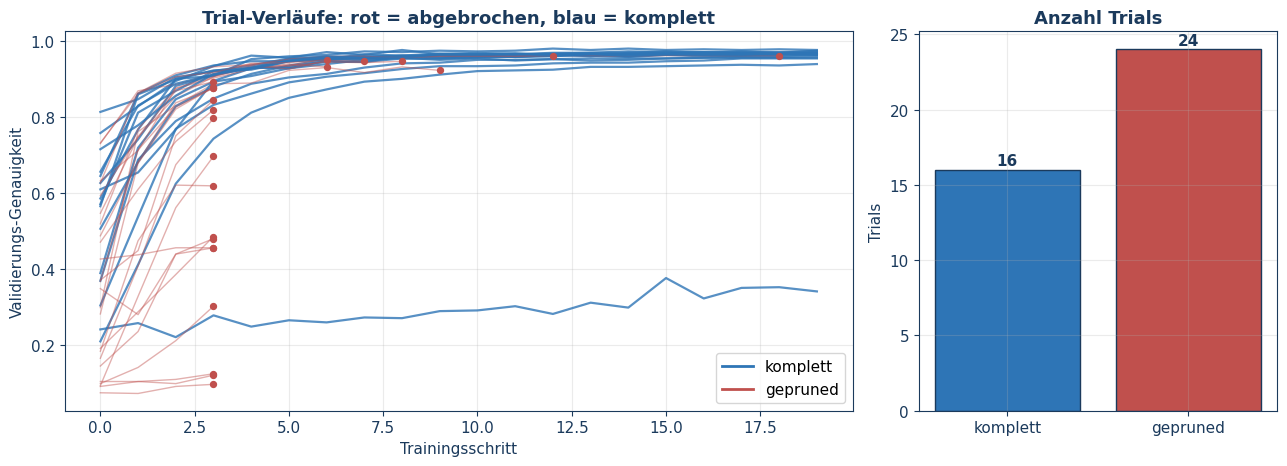

In [13]:
fig, (g1, g2) = plt.subplots(1, 2, figsize=(13, 4.8),
                             gridspec_kw={"width_ratios": [2.2, 1]})
for t in study.trials:
    iv = t.intermediate_values
    if not iv: continue
    xs = sorted(iv); ys = [iv[s] for s in xs]
    if t.state.name == "PRUNED":
        g1.plot(xs, ys, color=PRUNE, alpha=0.45, lw=1)
        g1.scatter(xs[-1], ys[-1], color=PRUNE, s=18, zorder=3)   # Abbruchpunkt
    else:
        g1.plot(xs, ys, color=MID, alpha=0.8, lw=1.6)
g1.set_xlabel("Trainingsschritt"); g1.set_ylabel("Validierungs-Genauigkeit")
g1.set_title("Trial-Verläufe: rot = abgebrochen, blau = komplett")
from matplotlib.lines import Line2D
g1.legend(handles=[Line2D([0],[0],color=MID,lw=2,label="komplett"),
                   Line2D([0],[0],color=PRUNE,lw=2,label="gepruned")], loc="lower right")

n_pr = sum(t.state.name=="PRUNED" for t in study.trials)
n_co = sum(t.state.name=="COMPLETE" for t in study.trials)
g2.bar(["komplett", "gepruned"], [n_co, n_pr], color=[MID, PRUNE], edgecolor=DARK)
g2.set_title("Anzahl Trials"); g2.set_ylabel("Trials")
for i, v in enumerate([n_co, n_pr]):
    g2.text(i, v+0.3, str(v), ha="center", fontweight="bold", color=DARK)
plt.tight_layout(); plt.show()

---
# Zusammenfassung

| | Baum-Pruning | NN-Pruning | Optuna-Pruning |
|---|---|---|---|
| **Was wird entfernt?** | Knoten / Teilbäume | Gewichte / Neuronen | aussichtslose Trials |
| **Steuergröße** | `ccp_alpha`, `max_depth` | Sparsity-Anteil | Pruner-Strategie (Median, …) |
| **Hauptziel** | weniger Overfitting | Kompression & Tempo | Rechenzeit sparen |
| **Wann?** | nach (Post) / vor (Pre) dem Training | meist **nach** dem Training | **während** der Suche |

**Roter Faden:** In allen drei Fällen gilt dasselbe Prinzip — *„Was wenig beiträgt, wird entfernt."* Weniger Komplexität → bessere Generalisierung, kleinere/schnellere Modelle, gesparte Ressourcen.

**Merksatz:**
> Ein Modell ohne Pruning ist wie ein Aufsatz ohne Überarbeitung: Es steht *alles* drin — auch das Überflüssige. Pruning ist das Streichen der Sätze, die nichts beitragen.